# Illustrative Example 2: GP Integration — Lorenz Attractor

This notebook demonstrates **GP-based integration** of a noisy time series using the Matérn 5/2 state-space model.

**Task**: given noisy observations of the first derivative $\dot{x}(t)$ (velocity), recover the original signal $x(t)$ by integration.

Reproduces Figure 4 from:
> *Differentiation and Integration of Time Series via Gaussian Process Regression for Structural Health Monitoring Applications*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from data_generation import generate_data_Lorenz_attractor, add_measurement_noise
from gp_optimization import optimize_hyperparams_Matern52_and_measurement_noise
import KalmanFilter_functions as KF
from plotting_functions import plot_states_with_zoom

## 1. Data Generation

We simulate the Lorenz attractor and use the first state's **derivative** as the measurement (i.e. we observe the velocity and want to recover the displacement by integration).

The mean is subtracted from the state since a constant offset cannot be recovered by integration alone.

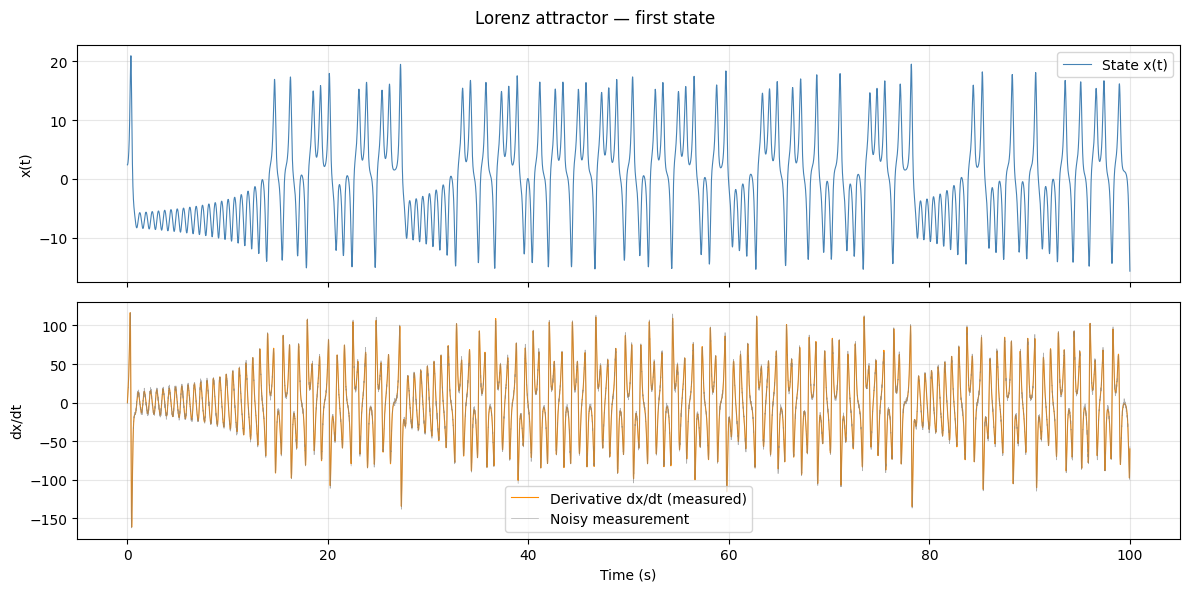

In [2]:
t, states, derivatives = generate_data_Lorenz_attractor()

# Subtract the mean (cannot be retrieved from integration)
states = states - np.mean(states, axis=0, keepdims=True)

dt      = t[1] - t[0]
n_steps = len(t)

# Add measurement noise to the first derivative (velocity)
noise_level = 0.05
meas_clean  = derivatives[:, 0]
meas_noisy, noise_std, R = add_measurement_noise(meas_clean, noise_fraction=noise_level, seed=456)

# Visualise
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t, states[:, 0],      color="steelblue",  lw=0.8, label="State x(t)")
axs[1].plot(t, derivatives[:, 0], color="darkorange",  lw=0.8, label="Derivative dx/dt (measured)")
axs[1].plot(t, meas_noisy,        color="gray",        lw=0.5, alpha=0.6, label="Noisy measurement")
for ax, label in zip(axs, ["x(t)", "dx/dt"]):
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
axs[-1].set_xlabel("Time (s)")
fig.suptitle("Lorenz attractor — first state")
plt.tight_layout()
plt.show()

## 2. Matérn 5/2 State-Space Model

Same state-space representation as Example 1. Because the GP state $\mathbf{z} = [x,\, \dot{x},\, \ddot{x}]^\top$ contains both the integral and the derivative, **integration is simply reading out $x(t)$ while observing $\dot{x}(t)$**.

In [3]:
def Matern52(l_f, sig_f, dt):
    """
    Matérn 5/2 state-space matrices (p=2).

    Parameters
    ----------
    l_f   : length scale
    sig_f : output standard deviation (sqrt of process variance)
    dt    : sampling interval

    Returns
    -------
    A     : discrete-time transition matrix  (3x3)
    Qd    : discrete-time process noise covariance  (3x3)
    Pinf  : stationary covariance  (3x3)
    D0    : output matrix — selects x(t)        (1x3)
    D1    : output matrix — selects dx/dt       (1x3)
    D2    : output matrix — selects d²x/dt²     (1x3)
    """
    p  = 2
    ni = p + 0.5
    lambda_ = (2 * ni) ** 0.5 / l_f
    q = 16 / 3 * sig_f ** 2 * lambda_ ** 5

    D0 = np.array([[1, 0, 0]])
    D1 = np.array([[0, 1, 0]])
    D2 = np.array([[0, 0, 1]])

    e   = np.exp(-lambda_ * dt)
    ldt = lambda_ * dt
    A = e * np.array([
        [1 + ldt + ldt**2 / 2,          dt * (1 + ldt),            dt**2 / 2            ],
        [-lambda_**3 * dt**2 / 2,        1 + ldt - ldt**2,           dt * (1 - ldt / 2)   ],
        [lambda_**4 * dt**2 / 2 - lambda_**3 * dt,
         lambda_**3 * dt**2 - 3 * lambda_**2 * dt,
         1 - 2 * ldt + ldt**2 / 2]
    ])

    Pinf = sig_f**2 * np.array([
        [1,               0,           -lambda_**2 / 3],
        [0,      lambda_**2 / 3,        0             ],
        [-lambda_**2 / 3, 0,             lambda_**4   ]
    ])

    Qd = Pinf - A @ Pinf @ A.T

    return A, Qd, Pinf, D0, D1, D2

## 3. Hyperparameter Optimization

`observed_derivative = 1` tells the model that it observes the **first derivative** $\dot{x}(t)$.  The NLL is minimised over $(l_f, \sigma_f, \sigma_n^2)$.

In [4]:
observed_derivative = 1  # we observe dx/dt → integrate to get x(t)

bounds_log = [
    (np.log(0.01), np.log(100)),
    (np.log(0.01), np.log(100)),
    (np.log(R[0, 0] / 100), np.log(R[0, 0] * 100))
]
initial_params = np.array([1., 1., R[0, 0] * 10])

params_opt, result = optimize_hyperparams_Matern52_and_measurement_noise(
    meas_noisy, dt,
    initial_params, bounds_log,
    observed_derivative,
)

l_f, sig_f, sigma2_n = params_opt
print(f"Optimised  l_f={l_f:.4f}  sig_f={sig_f:.4f}  sigma2_n={sigma2_n:.6f}")

Iteration 1  negLogLike: 196453.0  params: [ 1.          1.         44.84716096]


Iteration 2  negLogLike: 196453.0  params: [ 1.00000001  1.         44.84716096]


Iteration 3  negLogLike: 196453.0  params: [ 1.          1.00000001 44.84716096]


Iteration 4  negLogLike: 196453.0  params: [ 1.          1.         44.84716141]


Iteration 5  negLogLike: 103264.0  params: [1.0000000e-02 1.0000000e+02 4.4847161e+02]


...

Iteration 96  negLogLike: 27375.0  params: [ 0.44805054 14.78492666  4.11000463]


Iteration 97  negLogLike: 27375.0  params: [ 0.46274351 16.07196401  4.08412127]


Iteration 98  negLogLike: 27375.0  params: [ 0.46274351 16.07196401  4.08412127]


Iteration 99  negLogLike: 27375.0  params: [ 0.46274351 16.07196417  4.08412127]


Iteration 100  negLogLike: 27375.0  params: [ 0.46274351 16.07196401  4.08412132]
Optimized parameters: [ 0.46274351 16.07196401  4.08412127]
Final neg-log-likelihood: 27374.573586720187
Optimised  l_f=0.4627  sig_f=16.0720  sigma2_n=4.084121


## 4. GP Regression via Kalman Filter + RTS Smoother

P:\Postdoc_2025_2027\2026_02_February\revision_paper_GP\GP‑DiffInt\notebooks\plotting_functions.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize=fontsize_legends)


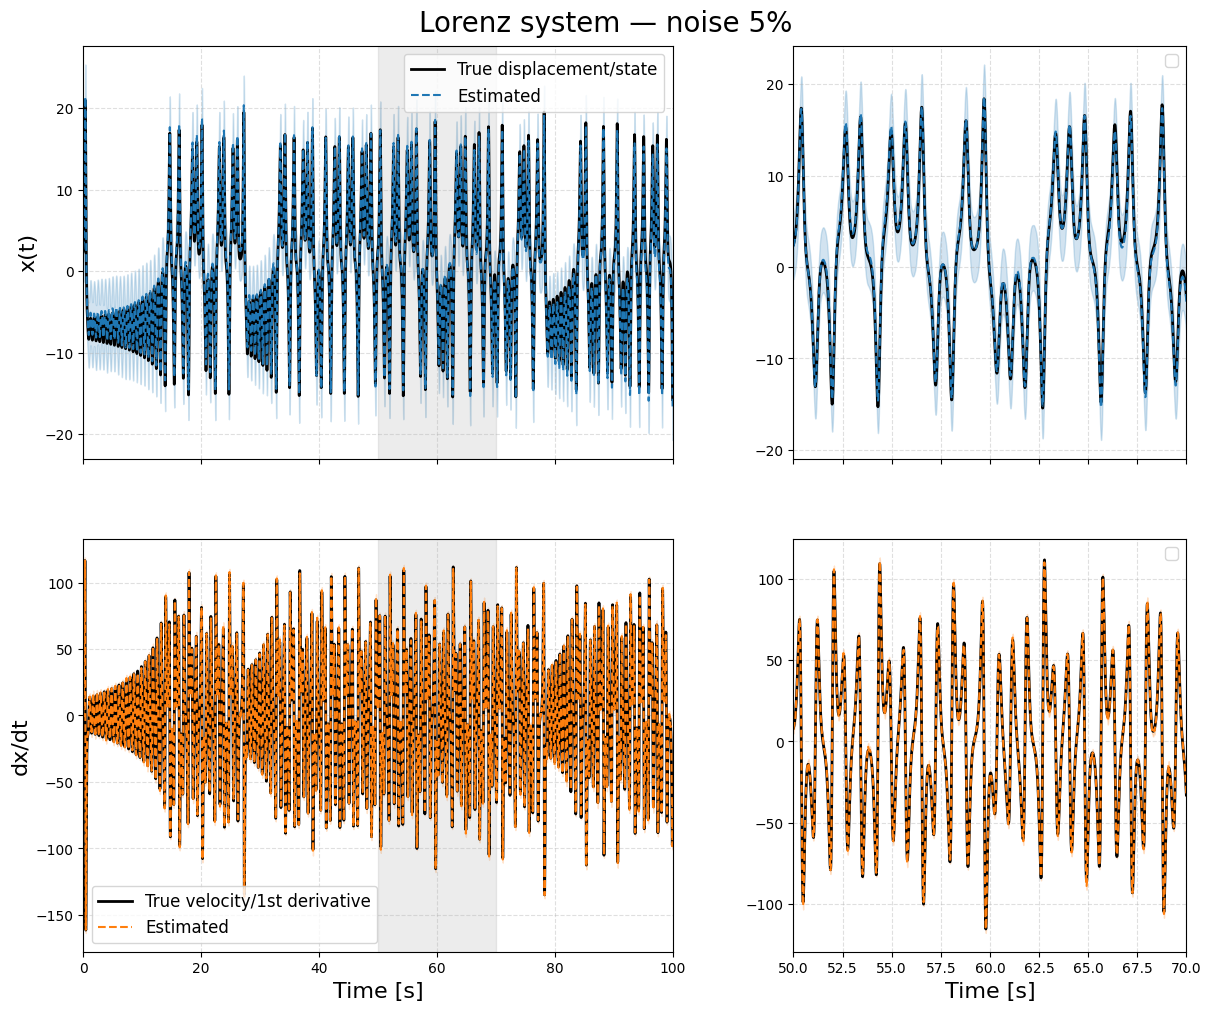

In [5]:
R_opt = sigma2_n * np.eye(1)

A, Qd, Pinf, D0, D1, D2 = Matern52(l_f, sig_f, dt)
H = [D0, D1, D2][observed_derivative]

# Kalman filter
zf, Pf = KF.kf_full_estimation(A, H, Qd, R_opt, meas_noisy.reshape(1, -1),
                                z0=np.zeros(3), P0=Pinf, return_nll=False)

# RTS smoother
zs, Ps = KF.rtss_full_estimation(A, zf, Pf, Qd)

# Extract estimates (only displacement and velocity — no acceleration panel)
displacement          = np.zeros(n_steps)
displacement_variance = np.zeros(n_steps)
velocity              = np.zeros(n_steps)
velocity_variance     = np.zeros(n_steps)

for k in range(n_steps):
    displacement[k]          = (D0 @ zs[:, k]).item()
    displacement_variance[k] = (D0 @ Ps[:, :, k] @ D0.T).item()
    velocity[k]              = (D1 @ zs[:, k]).item()
    velocity_variance[k]     = (D1 @ Ps[:, :, k] @ D1.T).item()

# Plot (2-panel: x and dx/dt)
fig, axs, axs_zoom = plot_states_with_zoom(
    t, states, derivatives,
    displacement, velocity, np.zeros(n_steps),
    displacement_variance, velocity_variance, np.zeros(n_steps),
    t_full_min=0.0, t_full_max=t[-1],
    t_zoom_min=50,  t_zoom_max=70,
    fontsize_axes=16, fontsize_legends=12,
    save_path=None, figsize=(12, 10),
    n_panels=2
)
fig.set_constrained_layout(True)
fig.suptitle(f"Lorenz system — noise {noise_level*100:.0f}%", fontsize=20)
plt.show()

## 5. (Optional) Comparison with Classical Integration Methods

Compares the GP approach against:
- **Frequency-domain integration** with high-pass filter (HP + FFT)
- **Tikhonov-regularised** integration
- **Savitzky–Golay** smoothing + trapezoidal integration

C:\Users\lucag\AppData\Local\Temp\ipykernel_27644\3082477123.py:26: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = sparse.diags([1, -1], [0, -1], shape=(N, N)) / dt


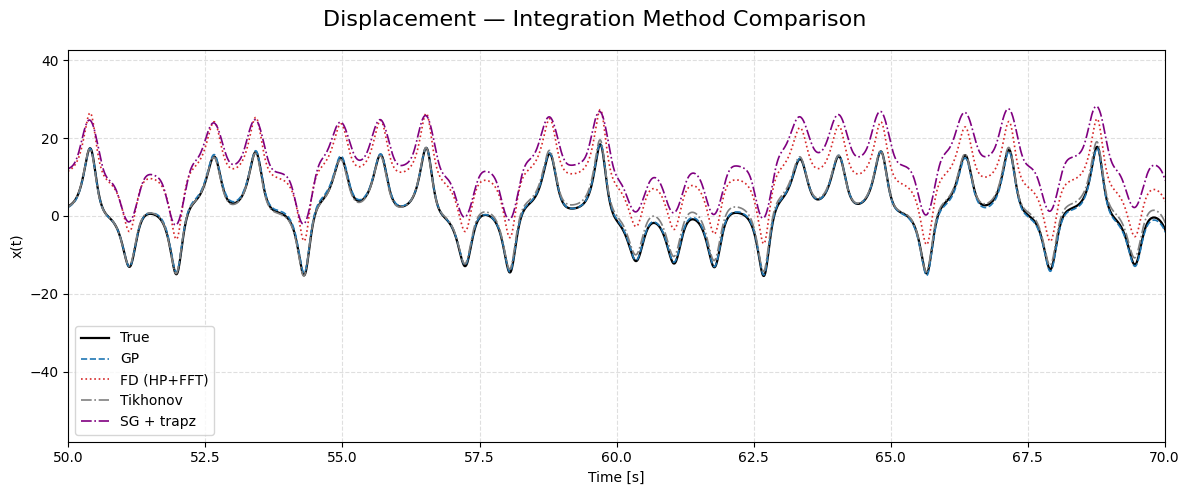

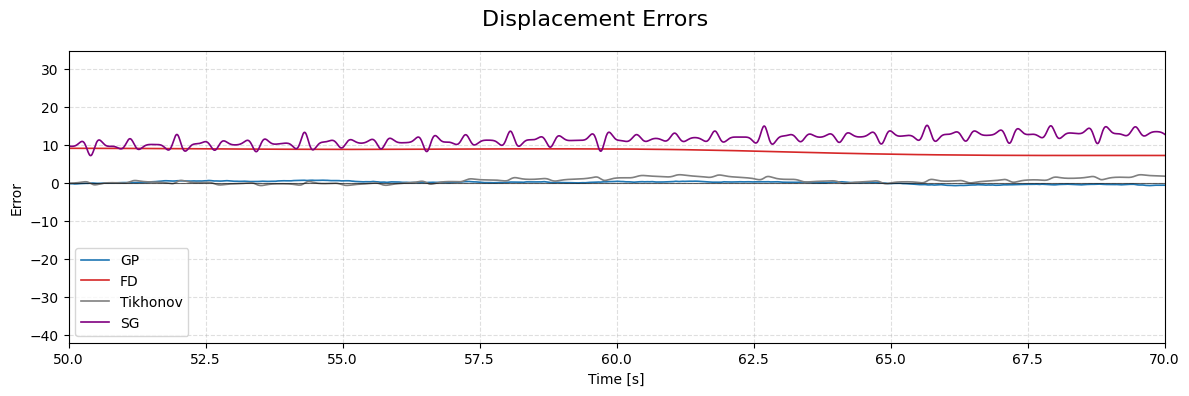

In [6]:
from scipy.signal import butter, sosfiltfilt, savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from numpy.fft import fft, ifft, fftfreq

# --- 1. Frequency-domain integration with high-pass ---
def integrate_freq_domain(vel, dt, f_hp=0.05, order=2):
    N   = len(vel)
    fs  = 1.0 / dt
    nyq = fs / 2.0
    sos     = butter(order, f_hp / nyq, btype='high', output='sos')
    vel_hp  = sosfiltfilt(sos, vel)
    freqs   = fftfreq(N, d=dt)
    V       = fft(vel_hp)
    X       = np.zeros_like(V, dtype=complex)
    denom   = 1j * 2 * np.pi * freqs
    nz      = np.abs(freqs) > 0
    X[nz]   = V[nz] / denom[nz]
    x       = ifft(X).real
    x      -= x[0]
    return x

# --- 2. Tikhonov-regularised integration ---
def tikhonov_integration(vel, dt, lam=1e-2, x0=0.0, anchor_strength=1e6):
    N = len(vel)
    D = sparse.diags([1, -1], [0, -1], shape=(N, N)) / dt
    I = sparse.eye(N)
    A_mat = D.T @ D + lam * I
    b     = D.T @ vel
    A_mat = A_mat.tolil()
    A_mat[0, 0] += anchor_strength
    b = b.copy()
    b[0] += anchor_strength * x0
    x = spsolve(A_mat.tocsc(), b)
    return x

# --- 3. Savitzky-Golay + trapezoidal integration ---
def savgol_integration(vel, dt, window=51, poly=3, detrend=True):
    if window % 2 == 0:
        window += 1
    v   = vel - np.mean(vel) if detrend else vel
    v_s = savgol_filter(v, window_length=window, polyorder=poly)
    x   = np.concatenate([[0.0], np.cumsum((v_s[:-1] + v_s[1:]) * 0.5 * dt)])
    return x

vel_meas = derivatives[:, 0]
x_gp  = displacement
x_fd  = integrate_freq_domain(vel_meas, dt, f_hp=0.05, order=2)
x_tik = tikhonov_integration(vel_meas,  dt, lam=1e-1, x0=0.0)
x_sg  = savgol_integration(vel_meas,    dt, window=51, poly=3, detrend=True)

x_true = states[:, 0]
for arr in (x_fd, x_tik, x_sg):
    arr += (x_true[0] - arr[0])

# ---- Comparison plot ----
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, x_true, 'k',             lw=1.6, label="True")
ax.plot(t, x_gp,   color="tab:blue",  ls="--", lw=1.2, label="GP")
ax.plot(t, x_fd,   color="tab:red",   ls=":",  lw=1.2, label="FD (HP+FFT)")
ax.plot(t, x_tik,  color="gray",      ls="-.", lw=1.2, label="Tikhonov")
ax.plot(t, x_sg,   color="purple",    ls="-.", lw=1.2, label="SG + trapz")
ax.set_xlim(50, 70)
ax.set_xlabel("Time [s]"); ax.set_ylabel("x(t)")
ax.legend(); ax.grid(True, ls="--", alpha=0.4)
fig.suptitle("Displacement — Integration Method Comparison", fontsize=16)
plt.tight_layout()
plt.show()

# ---- Error plot ----
fig, ax = plt.subplots(figsize=(12, 4))
for label, arr, color in [("GP", x_gp, "tab:blue"), ("FD", x_fd, "tab:red"),
                           ("Tikhonov", x_tik, "gray"), ("SG", x_sg, "purple")]:
    ax.plot(t, arr - x_true, lw=1.2, color=color, label=label)
ax.axhline(0, color="k", lw=0.8, alpha=0.6)
ax.set_xlim(50, 70)
ax.set_xlabel("Time [s]"); ax.set_ylabel("Error")
ax.legend(); ax.grid(True, ls="--", alpha=0.4)
fig.suptitle("Displacement Errors", fontsize=16)
plt.tight_layout()
plt.show()